In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

In [5]:
merged_df = pd.read_csv("dataset_merged.csv")

/tmp/ipykernel_110/2445246713.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  merged_df = pd.read_csv("dataset_merged.csv")


In [4]:
print("Dataset shape:", merged_df.shape)

merged_df.info()

merged_df.describe()

Dataset shape: (1599858, 41)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599858 entries, 0 to 1599857
Data columns (total 41 columns):
 #   Column                         Non-Null Count    Dtype  
---  ------                         --------------    -----  
 0   CRASH DATE                     1599858 non-null  object 
 1   CRASH TIME                     1599858 non-null  object 
 2   BOROUGH                        1599858 non-null  object 
 3   ZIP CODE                       1159828 non-null  object 
 4   LATITUDE                       1562065 non-null  float64
 5   LONGITUDE                      1562065 non-null  float64
 6   LOCATION                       1562065 non-null  object 
 7   NUMBER OF PERSONS INJURED      1599858 non-null  float64
 8   NUMBER OF PERSONS KILLED       1599858 non-null  float64
 9   NUMBER OF PEDESTRIANS INJURED  1599858 non-null  int64  
 10  NUMBER OF PEDESTRIANS KILLED   1599858 non-null  int64  
 11  NUMBER OF CYCLIST INJURED      1599858 non-null

,LATITUDE,LONGITUDE,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,NUMBER OF CYCLIST INJURED,NUMBER OF CYCLIST KILLED,NUMBER OF MOTORIST INJURED,NUMBER OF MOTORIST KILLED,...,wind_speed_10m (km/h),traffic_volume,start_count,end_count,active_construction,construction_change,alteration,demolition,new_building,other
count,1.562065e+06,1.562065e+06,1.599858e+06,1.599858e+06,1.599858e+06,1.599858e+06,1.599858e+06,1.599858e+06,1.599858e+06,1.599858e+06,...,1.599858e+06,1.599858e+06,1.599858e+06,1.599858e+06,1.599858e+06,1.599858e+06,1.418276e+06,1.418276e+06,1.418276e+06,1.418276e+06
mean,4.054778e+01,-7.360637e+01,3.491710e-01,1.623269e-03,6.330874e-02,8.088218e-04,3.292105e-02,1.462630e-04,2.466181e-01,6.263056e-04,...,1.335997e+01,1.245856e+02,7.162419e+01,8.137701e+01,3.439944e+04,-9.752811e+00,7.269446e+01,2.255024e+00,4.287391e+00,1.557369e+00
std,2.676397e+00,4.970892e+00,7.240898e-01,4.244881e-02,2.568149e-01,2.923050e-02,1.809381e-01,1.214462e-02,6.844975e-01,2.705870e-02,...,6.988411e+00,3.954853e+01,8.393943e+01,9.133235e+01,2.870107e+04,4.155171e+01,8.006643e+01,3.892705e+00,7.006916e+00,2.498727e+00
min,0.000000e+00,-2.013600e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,1.377656e+01,0.000000e+00,0.000000e+00,0.000000e+00,-5.420000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,4.066708e+01,-7.397213e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,8.200000e+00,1.144583e+02,4.000000e+00,6.000000e+00,1.029500e+04,-2.100000e+01,7.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,4.071933e+01,-7.392416e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,1.220000e+01,1.267166e+02,3.500000e+01,4.900000e+01,3.328800e+04,-1.000000e+00,4.200000e+01,0.000000e+00,1.000000e+00,0.000000e+00
75%,4.077135e+01,-7.386498e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,1.740000e+01,1.500342e+02,1.200000e+02,1.280000e+02,5.283200e+04,3.000000e+00,1.130000e+02,3.000000e+00,6.000000e+00,2.000000e+00
max,4.334444e+01,0.000000e+00,3.400000e+01,8.000000e+00,2.700000e+01,6.000000e+00,3.000000e+00,2.000000e+00,3.400000e+01,4.000000e+00,...,6.040000e+01,2.003190e+02,1.020000e+03,7.410000e+02,9.944500e+04,6.240000e+02,9.910000e+02,5.200000e+01,1.650000e+02,2.300000e+01


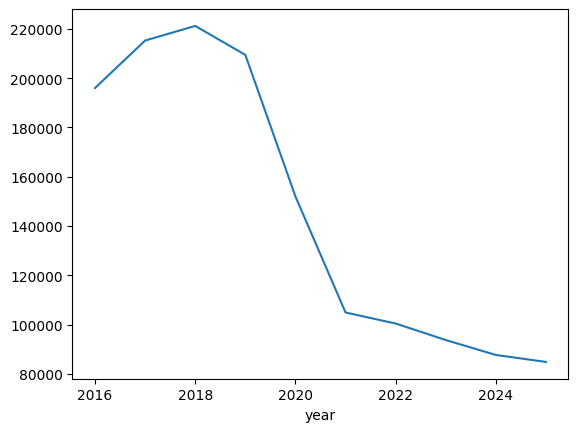

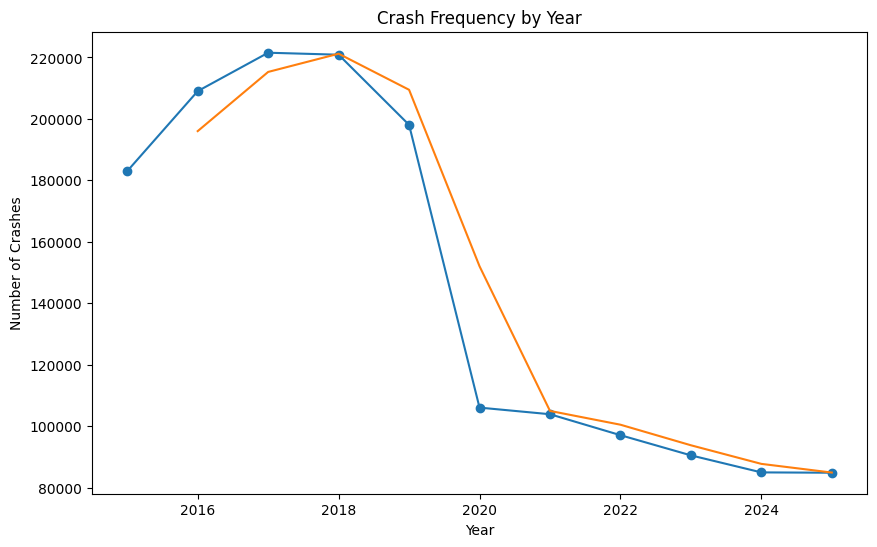

In [5]:
crashes_per_year = merged_df.groupby("year").size()

sns.lineplot(data=crashes_per_year.rolling(2).mean())


plt.figure(figsize=(10,6))

plt.plot(crashes_per_year.index, crashes_per_year.values, marker="o")

plt.title("Crash Frequency by Year")
plt.xlabel("Year")
plt.ylabel("Number of Crashes")
sns.lineplot(data=crashes_per_year.rolling(2).mean())

plt.show()

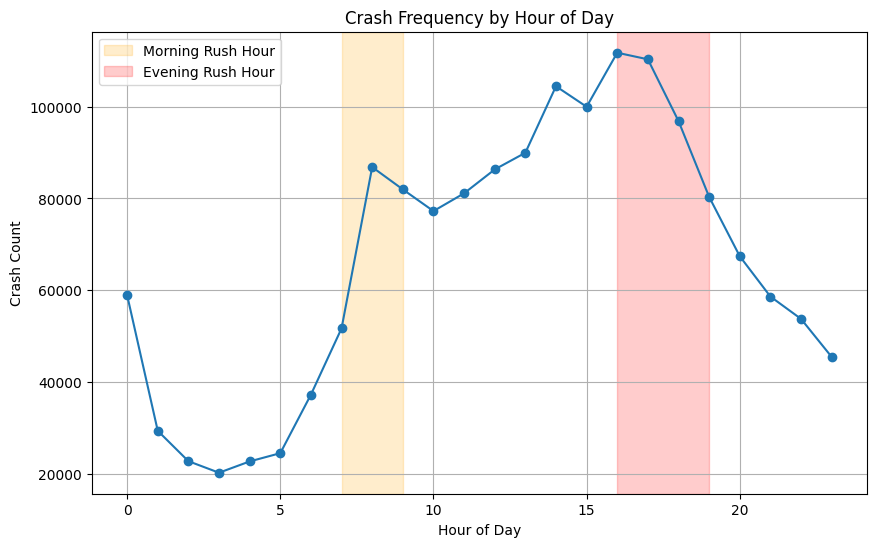

In [6]:
crashes_by_hour = merged_df.groupby("hour").size()

plt.figure(figsize=(10,6))

# Plot crash frequency
plt.plot(crashes_by_hour.index, crashes_by_hour.values, marker="o")

# Highlight morning rush hour (7–9)
plt.axvspan(7, 9, color="orange", alpha=0.2, label="Morning Rush Hour")

# Highlight evening rush hour (16–19)
plt.axvspan(16, 19, color="red", alpha=0.2, label="Evening Rush Hour")

plt.title("Crash Frequency by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Crash Count")

plt.legend()
plt.grid(True)

plt.show()

<img src="image-20260309-230739.png" width="" align="" />

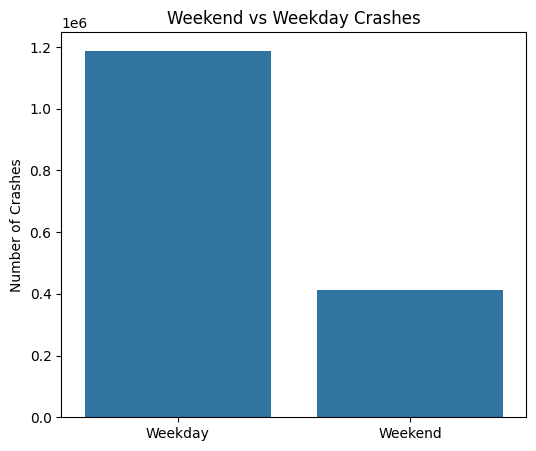

In [7]:
merged_df["date"] = pd.to_datetime(merged_df["date"])

merged_df["weekend"] = merged_df["date"].dt.dayofweek >= 5

weekend_counts = merged_df["weekend"].value_counts()

plt.figure(figsize=(6,5))

sns.barplot(
    x=["Weekday", "Weekend"],
    y=weekend_counts.values
)

plt.title("Weekend vs Weekday Crashes")
plt.ylabel("Number of Crashes")

plt.show()

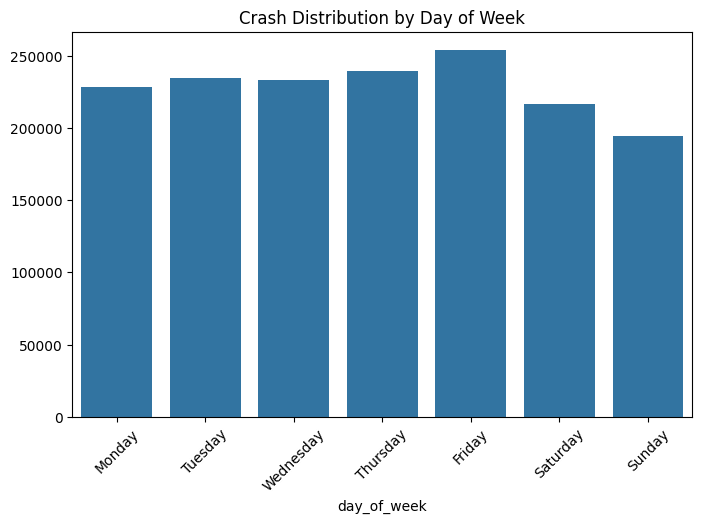

In [8]:
merged_df["day_of_week"] = merged_df["date"].dt.day_name()

day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

crashes_per_day = merged_df["day_of_week"].value_counts().reindex(day_order)

plt.figure(figsize=(8,5))

sns.barplot(x=crashes_per_day.index, y=crashes_per_day.values)

plt.title("Crash Distribution by Day of Week")

plt.xticks(rotation=45)

plt.show()

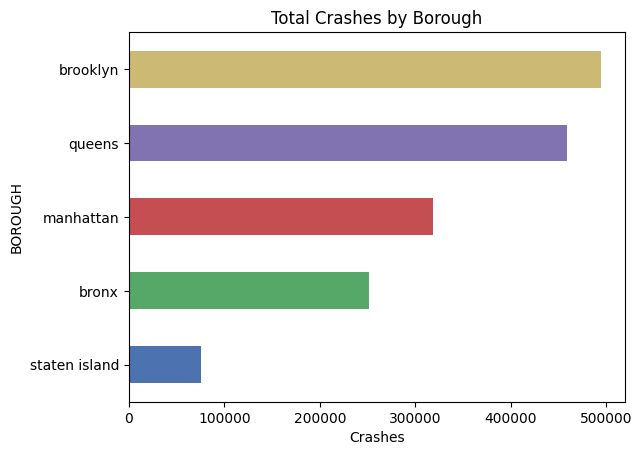

In [9]:
borough_totals =merged_df.groupby("BOROUGH").size().sort_values()

plt.figure()
borough_totals.plot(
    kind="barh",
    color=["#4C72B0","#55A868","#C44E52","#8172B2","#CCB974"]
)
plt.title("Total Crashes by Borough")
plt.xlabel("Crashes")
plt.show()

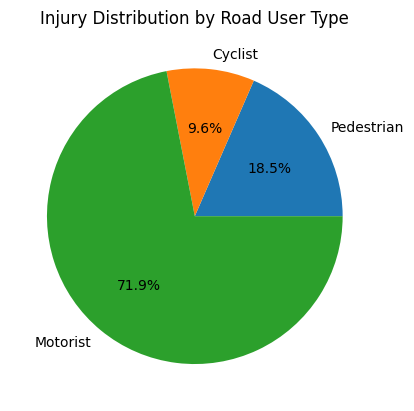

In [10]:
vru_totals = {
    "Pedestrian": merged_df["NUMBER OF PEDESTRIANS INJURED"].sum(),
    "Cyclist": merged_df["NUMBER OF CYCLIST INJURED"].sum(),
    "Motorist": merged_df["NUMBER OF MOTORIST INJURED"].sum()
}

plt.figure()
plt.pie(vru_totals.values(), labels=vru_totals.keys(), autopct="%1.1f%%")
plt.title("Injury Distribution by Road User Type")
plt.show()

In [11]:
daily_total = merged_df.groupby("CRASH DATE").size()
peak_day = daily_total.idxmax()
peak_value = daily_total.max()
low_day = daily_total.idxmin()
low_value = daily_total.min()

print("Peak crash day:", peak_day)
print("Crash count:", peak_value)

print("Lowest crash day:", low_day)
print("Crash count:", low_value)


Peak crash day: 2018-11-15
Crash count: 1006
Lowest crash day: 2020-04-05
Crash count: 89


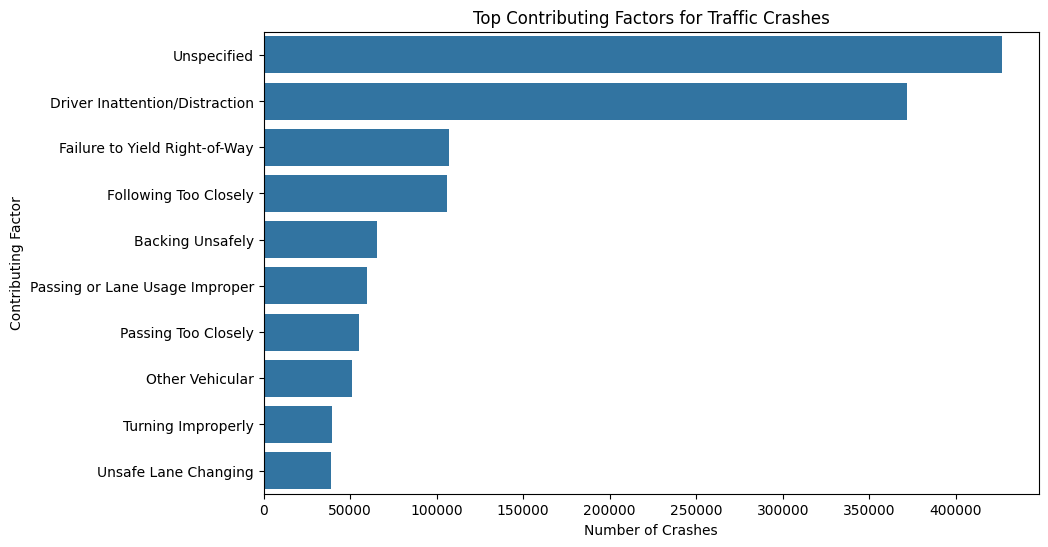

In [12]:
top_factors = (
    merged_df["CONTRIBUTING FACTOR VEHICLE 1"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_factors.values,
    y=top_factors.index
)

plt.title("Top Contributing Factors for Traffic Crashes")
plt.xlabel("Number of Crashes")
plt.ylabel("Contributing Factor")

plt.show()

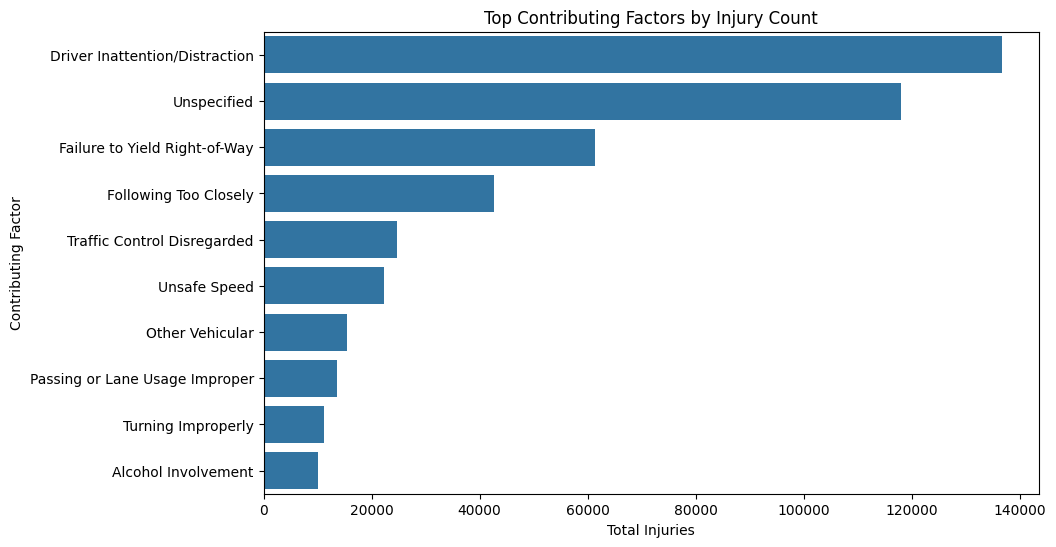

In [13]:
factor_injuries = (
    merged_df.groupby("CONTRIBUTING FACTOR VEHICLE 1")
    ["NUMBER OF PERSONS INJURED"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=factor_injuries.values,
    y=factor_injuries.index
)

plt.title("Top Contributing Factors by Injury Count")
plt.xlabel("Total Injuries")
plt.ylabel("Contributing Factor")

plt.show()

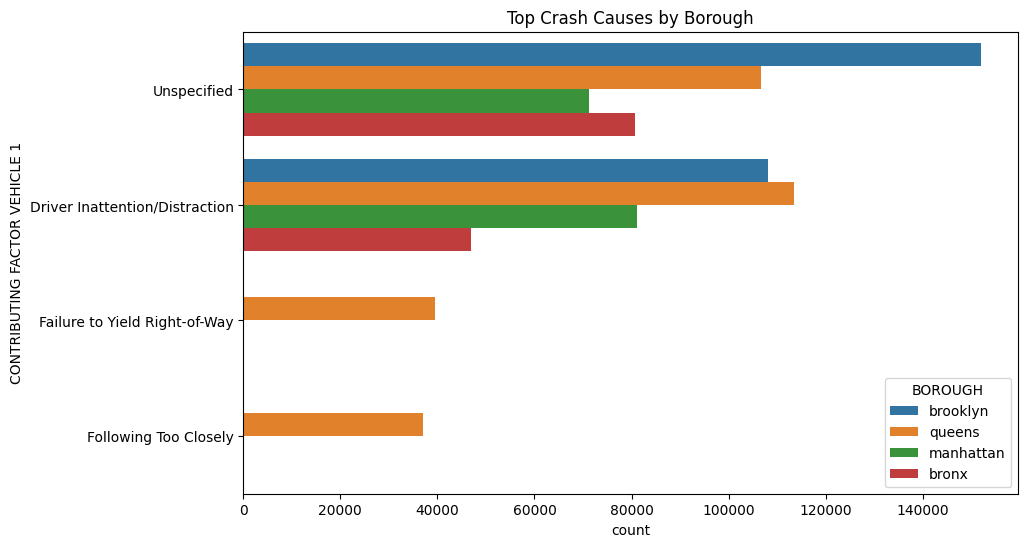

In [14]:
borough_factor = (
    merged_df.groupby(["BOROUGH","CONTRIBUTING FACTOR VEHICLE 1"])
    .size()
    .reset_index(name="count")
)

top10 = borough_factor.sort_values("count",ascending=False).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x="count",
    y="CONTRIBUTING FACTOR VEHICLE 1",
    hue="BOROUGH"
)

plt.title("Top Crash Causes by Borough")

plt.show()

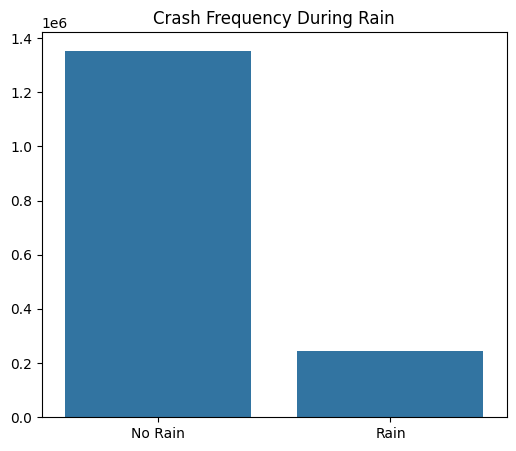

In [15]:
merged_df["rain_indicator"] = (merged_df["rain (mm)"] > 0).astype(int)

rain_counts = merged_df["rain_indicator"].value_counts()

plt.figure(figsize=(6,5))

sns.barplot(
    x=["No Rain","Rain"],
    y=rain_counts.values
)

plt.title("Crash Frequency During Rain")

plt.show()

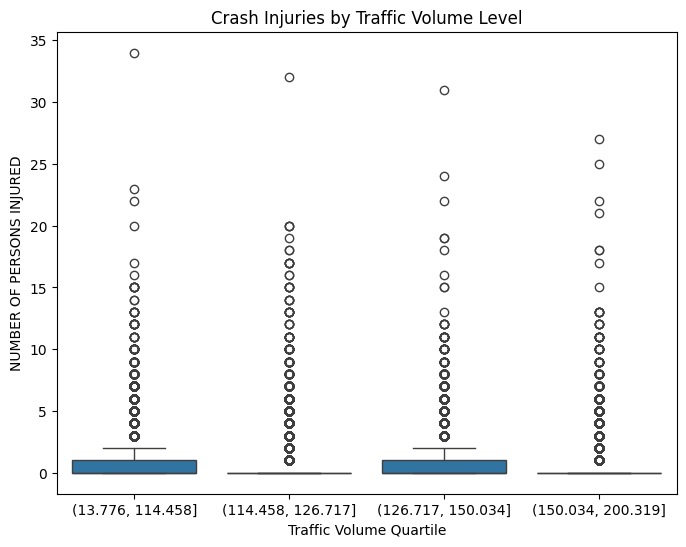

In [16]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x=pd.qcut(merged_df["traffic_volume"],4),
    y="NUMBER OF PERSONS INJURED",
    data=merged_df
)

plt.title("Crash Injuries by Traffic Volume Level")

plt.xlabel("Traffic Volume Quartile")

plt.show()

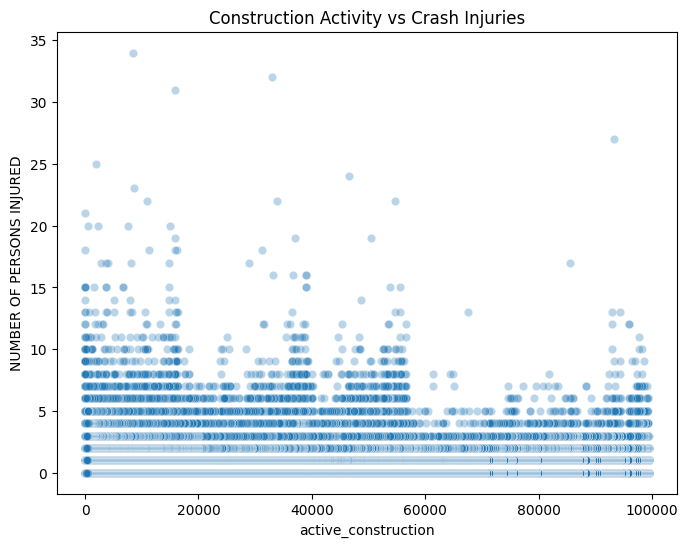

In [17]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=merged_df,
    x="active_construction",
    y="NUMBER OF PERSONS INJURED",
    alpha=0.3
)

plt.title("Construction Activity vs Crash Injuries")

plt.show()

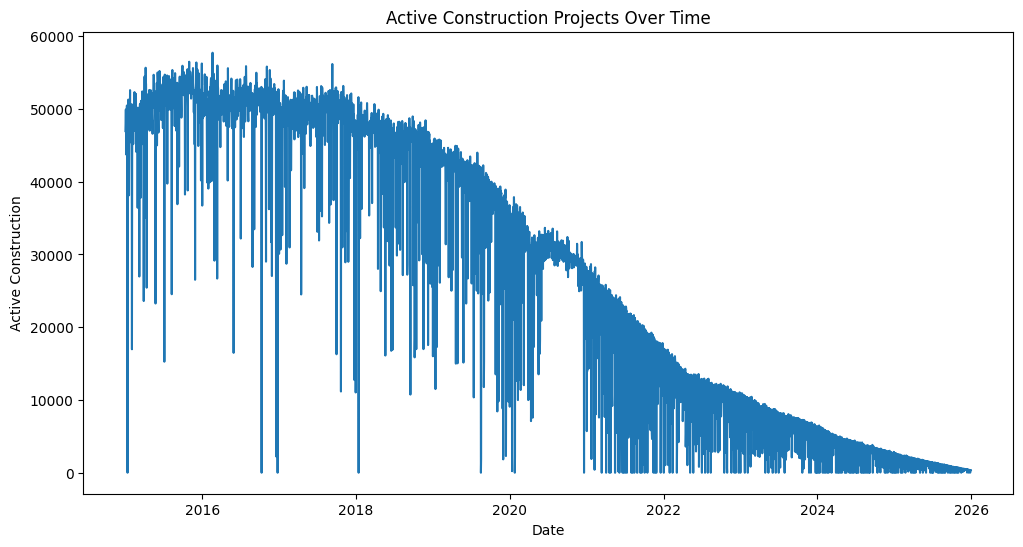

In [18]:
construction_trend = merged_df.groupby("date")["active_construction"].mean()

plt.figure(figsize=(12,6))

plt.plot(construction_trend.index, construction_trend.values)

plt.title("Active Construction Projects Over Time")
plt.xlabel("Date")
plt.ylabel("Active Construction")

plt.show()

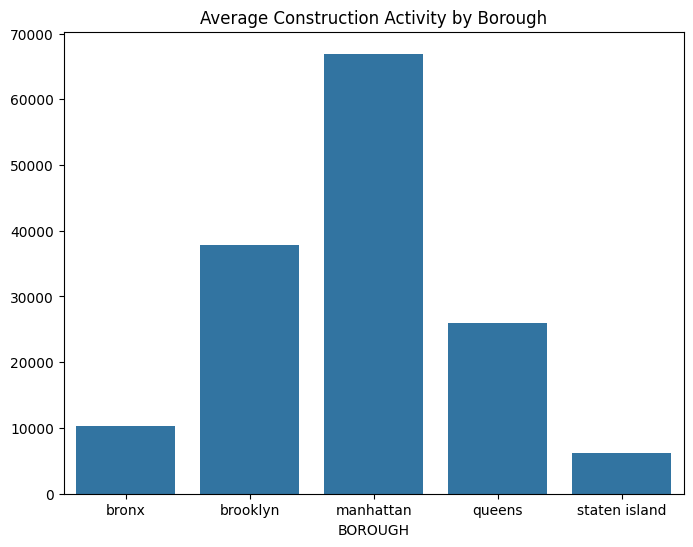

In [19]:
construction_borough = merged_df.groupby("BOROUGH")["active_construction"].mean()

plt.figure(figsize=(8,6))

sns.barplot(
    x=construction_borough.index,
    y=construction_borough.values
)

plt.title("Average Construction Activity by Borough")

plt.show()

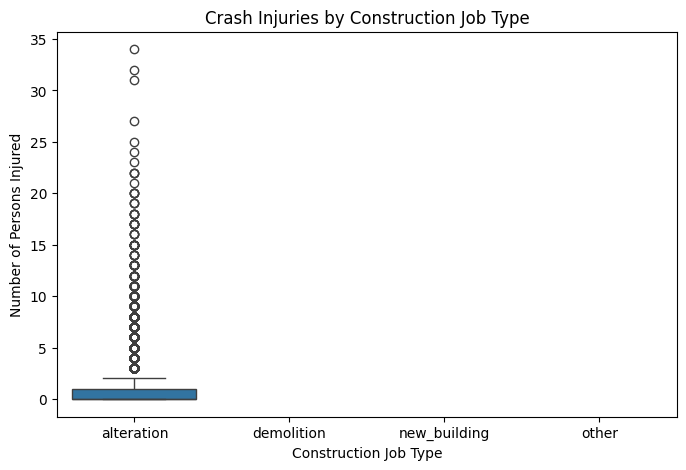

In [20]:
job_cols = ["alteration", "demolition", "new_building", "other"]

# Convert to long format
job_df = merged_df.melt(
    value_vars=job_cols,
    var_name="job_type",
    value_name="construction_activity"
)

# Add injury column
job_df["injuries"] = merged_df["NUMBER OF PERSONS INJURED"]

# Plot
plt.figure(figsize=(8,5))

sns.boxplot(
    data=job_df,
    x="job_type",
    y="injuries"
)

plt.title("Crash Injuries by Construction Job Type")
plt.xlabel("Construction Job Type")
plt.ylabel("Number of Persons Injured")

plt.show()

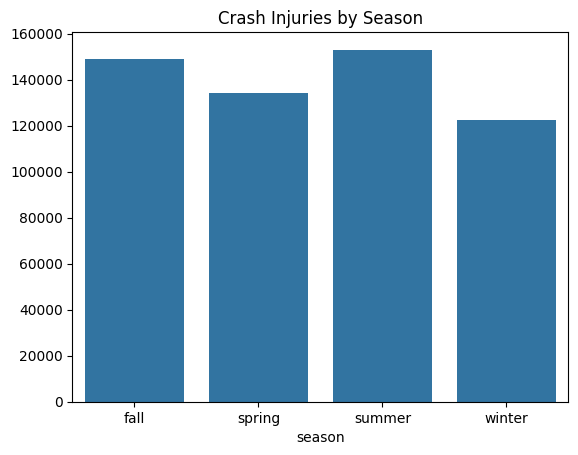

In [21]:
season_crashes = merged_df.groupby("season")["NUMBER OF PERSONS INJURED"].sum()

sns.barplot(
    x=season_crashes.index,
    y=season_crashes.values
)

plt.title("Crash Injuries by Season")

plt.show()

<Axes: xlabel='SEVERITY', ylabel='count'>

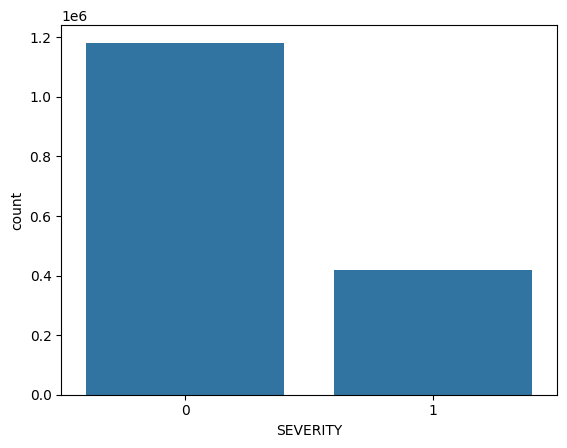

In [7]:
merged_df["SEVERITY"] = ((merged_df["NUMBER OF PERSONS KILLED"] > 0) | 
                  (merged_df["NUMBER OF PERSONS INJURED"] > 0)).astype(int)

sns.countplot(x="SEVERITY", data=merged_df)

<Axes: xlabel='hour', ylabel='count'>

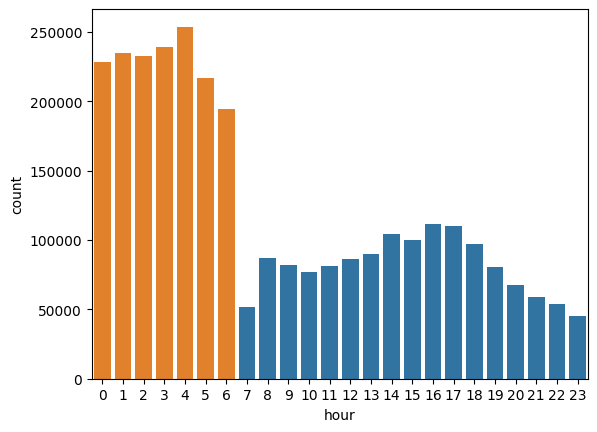

In [9]:
sns.countplot(x="hour", data=merged_df)
sns.countplot(x="day_of_week", data=merged_df)

<Axes: xlabel='SEVERITY', ylabel='rain (mm)'>

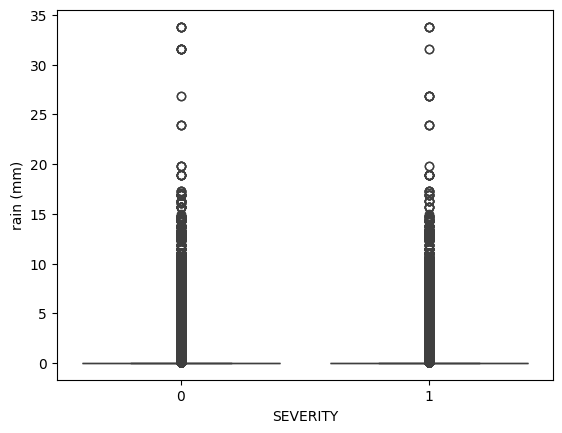

In [13]:
sns.boxplot(x="SEVERITY", y="rain (mm)", data=merged_df)

<Axes: xlabel='SEVERITY', ylabel='traffic_volume'>

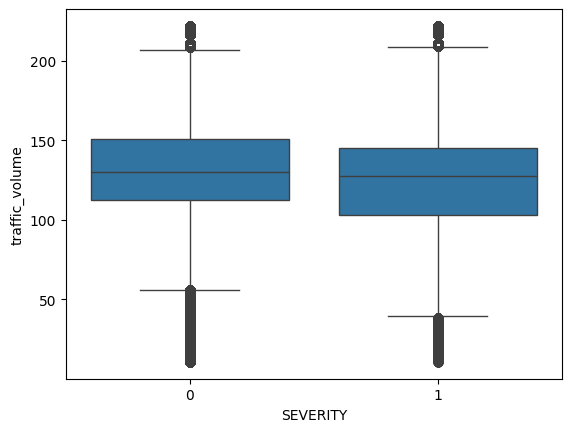

In [17]:
sns.boxplot(x="SEVERITY", y="traffic_volume", data=merged_df)

<Axes: xlabel='SEVERITY', ylabel='active_construction'>

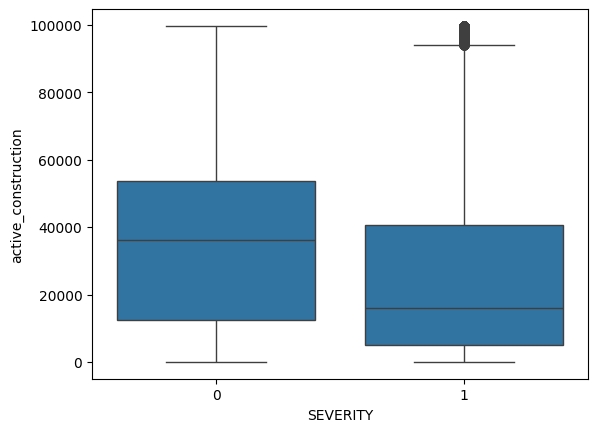

In [19]:
sns.boxplot(x="SEVERITY", y="active_construction", data=merged_df)

<Axes: xlabel='SEVERITY', ylabel='rain_traffic'>

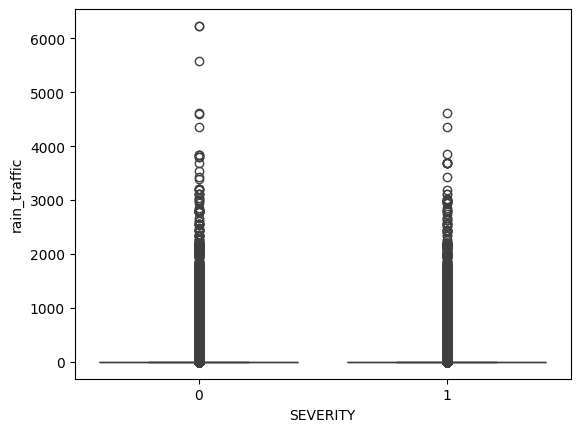

In [21]:
merged_df["rain_traffic"] = merged_df["rain (mm)"] * merged_df["traffic_volume"]

sns.boxplot(x="SEVERITY", y="rain_traffic", data=merged_df)